### SetUp

In [14]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [15]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
import pathlib
import keras_hub
from keras import ops
import json
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from matplotlib.patches import Rectangle
import math
import random



In [16]:
print("Is PyTorch utilizing the GPU?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device Name:", torch.cuda.get_device_name(0))

Is PyTorch utilizing the GPU?: False


## Object Segment

### Load Dataset & data Preprocessing

In [4]:
# Load Dataset
input_dir = pathlib.Path(r"C:\Users\PRASHANTH N\PycharmProjects\MTechSem2\DLRL\BOOKS\1\chapter11\dataset\images")
target_dir = pathlib.Path(r"C:\Users\PRASHANTH N\PycharmProjects\MTechSem2\DLRL\BOOKS\1\chapter11\dataset\annotations\trimaps")
input_img_paths = sorted(input_dir.glob("*.jpg"))
target_paths = sorted(target_dir.glob("[!.]*.png"))
len(input_img_paths), len(target_paths)

(7390, 7390)

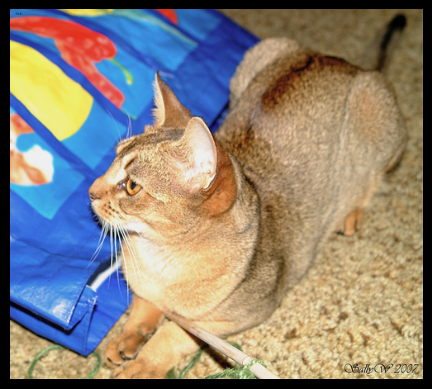

In [5]:
# Sample Image
plt.axis("off")
plt.imshow(keras.utils.load_img(input_img_paths[9]))

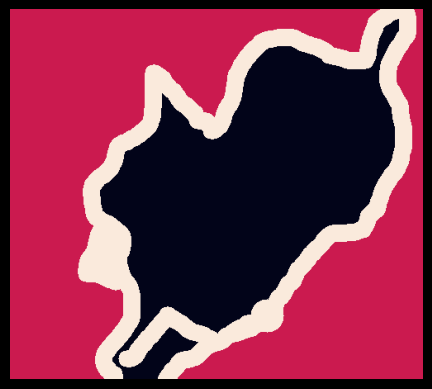

In [6]:
# Sample Target
plt.axis("off")
plt.imshow(keras.utils.load_img(target_paths[9], color_mode="grayscale"))

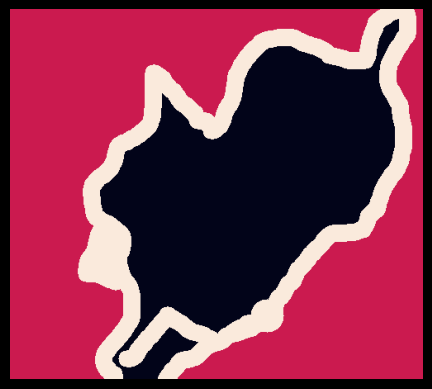

In [7]:
# Normalized Target
def display_target(target_array):
    normalized_array = (target_array.astype("uint8") - 1) * 127
    plt.axis("off")
    plt.imshow(normalized_array[:, :, 0])

img = keras.utils.img_to_array(keras.utils.load_img(target_paths[9], color_mode="grayscale"))
display_target(img)

In [8]:
# utility Functions
img_size = (200, 200)
num_imgs = len(input_img_paths)

random.Random(1337).shuffle(input_img_paths)
random.Random(1337).shuffle(target_paths)

def path_to_input_image(path):
    return keras.utils.img_to_array(keras.utils.load_img(path, target_size=img_size))

def path_to_target(path):
    img = keras.utils.img_to_array(keras.utils.load_img(path, target_size=img_size, color_mode="grayscale"))
    img = img.astype("uint8") - 1
    return img

In [ ]:
# Storing image and target image as matrix vals
input_imgs = np.zeros((num_imgs,) + img_size + (3,), dtype="float32")
targets = np.zeros((num_imgs,) + img_size + (1,), dtype="uint8")

for i in range(num_imgs):
    input_imgs[i] = path_to_input_image(input_img_paths[i])
    targets[i] = path_to_target(target_paths[i])

In [ ]:
# Train & Val Split
num_val_samples = 1000
train_input_imgs = input_imgs[:-num_val_samples]
train_targets = targets[:-num_val_samples]
val_input_imgs = input_imgs[-num_val_samples:]
val_targets = targets[-num_val_samples:]

### Object Segment from Scratch

#### Model Arch

In [ ]:
def get_model(img_size, num_classes):
    inputs = keras.Input(shape=img_size + (3,))
    x = keras.layers.Rescaling(1.0 / 255)(inputs)
    x = keras.layers.Conv2D(64, 3, strides=2, activation="relu", padding="same")(x)
    x = keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = keras.layers.Conv2D(128, 3, strides=2, activation="relu", padding="same")(x)
    x = keras.layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = keras.layers.Conv2D(256, 3, strides=2, padding="same", activation="relu")(x)
    x = keras.layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    x = keras.layers.Conv2DTranspose(256, 3, activation="relu", padding="same")(x)
    x = keras.layers.Conv2DTranspose(256, 3, strides=2, activation="relu", padding="same")(x)
    x = keras.layers.Conv2DTranspose(128, 3, activation="relu", padding="same")(x)
    x = keras.layers.Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same")(x)
    x = keras.layers.Conv2DTranspose(64, 3, activation="relu", padding="same")(x)
    x = keras.layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
    outputs = keras.layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(x)
    return keras.Model(inputs, outputs)


model = get_model(img_size=img_size, num_classes=3)
model.summary()

#### Model Training

In [ ]:
# Custom Metric Function : IoU (Intersection over Union)

foreground_iou = keras.metrics.IoU(
    num_classes=3,
    target_class_ids=(0,),
    name="foreground_iou",
    sparse_y_true=True,
    sparse_y_pred=False,
)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[foreground_iou],
)

In [ ]:
# Save best Model callback
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "scratch_segmentation.keras",
        save_best_only=True,
    ),
]

In [ ]:
# Training
history = model.fit(
    train_input_imgs,
    train_targets,
    epochs=5,
    callbacks=callbacks,
    batch_size=64,
    validation_data=(val_input_imgs, val_targets),
)

#### Model Evaluation

In [ ]:
# Loss Plot - Train loss vs Validation loss
epochs = range(1, len(history.history["loss"]) + 1)
loss = history.history["loss"]
val_loss = history.history["val_loss"]
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()

In [ ]:
# Load Saved Model
model = keras.models.load_model("oxford_segmentation.keras")

In [ ]:
# Test Image to view model output
i = 4
test_image = val_input_imgs[i]
plt.axis("off")
plt.imshow(keras.utils.array_to_img(test_image))


In [ ]:
# Model Output of test Image

mask = model.predict(np.expand_dims(test_image, 0))[0]

def display_mask(pred):
    mask = np.argmax(pred, axis=-1)
    mask *= 127
    plt.axis("off")
    plt.imshow(mask)

display_mask(mask)

### Object Segment using Pretrained Model

#### Load Model

In [17]:
model = keras_hub.models.ImageSegmenter.from_preset("sam_huge_sa1b")
model.summary()

TypeError: <class 'keras_hub.src.models.sam.sam_image_segmenter.SAMImageSegmenter'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras_hub.src.models.sam.sam_image_segmenter', 'class_name': 'SAMImageSegmenter', 'config': {'backbone': <SAMBackbone name=sam_backbone, built=True>, 'preprocessor': {'module': 'keras_hub.src.models.sam.sam_image_segmenter_preprocessor', 'class_name': 'SAMImageSegmenterPreprocessor', 'config': {'name': 'sam_image_segmenter_preprocessor', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'image_converter': {'module': 'keras_hub.src.models.sam.sam_image_converter', 'class_name': 'SAMImageConverter', 'config': {'name': 'sam_image_converter', 'trainable': True, 'dtype': {'module': 'keras', 'cl

In [ ]:
model.count_params()

#### Utility Function

In [9]:
def show_image(image, ax):
    ax.imshow(ops.convert_to_numpy(image).astype("uint8"))

def show_mask(mask, ax):
    color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])
    h, w, _ = mask.shape
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(points, ax):
    x, y = points[:, 0], points[:, 1]
    ax.scatter(x, y, c="green", marker="*", s=375, ec="white", lw=1.25)

def show_box(box, ax):
    box = box.reshape(-1)
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, ec="red", fc="none", lw=2))

#### Load Test Image

259153/259153 ━━━━━━━━━━━━━━━━━━━━ 1s 3us/step


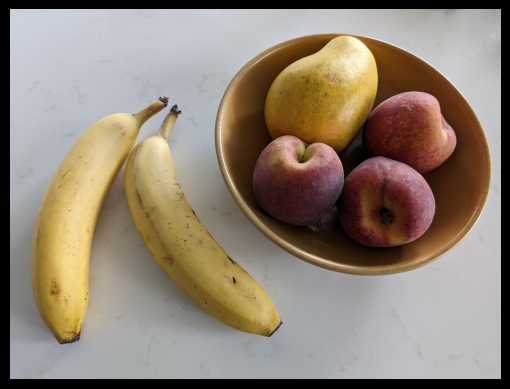

(1054, 1400, 3)


In [10]:
path = keras.utils.get_file(
    origin="https://s3.amazonaws.com/keras.io/img/book/fruits.jpg"
)
pil_image = keras.utils.load_img(path)
image_array = keras.utils.img_to_array(pil_image)
plt.imshow(image_array.astype("uint8"))
plt.axis("off")
plt.show()
print(image_array.shape)

In [11]:
image_size = (1024, 1024)
def resize_and_pad(x):
  return ops.image.resize(x, image_size, pad_to_aspect_ratio=True)
image = resize_and_pad(image_array)
image.shape

TensorShape([1024, 1024, 3])

#### Point prompt

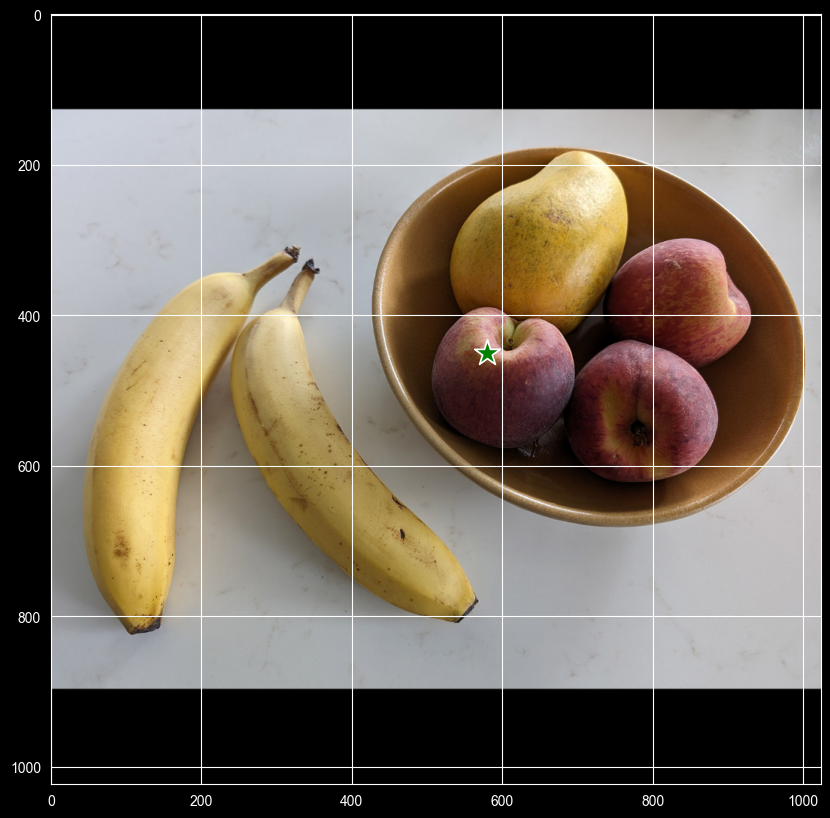

In [12]:
# Add Point to test Image
input_point = np.array([[580, 450]])
input_label = np.array([1])
plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_points(input_point, plt.gca())
plt.show()

In [13]:
# Inference the Model
outputs = model.predict(
{
"images": ops.expand_dims(image, axis=0),
"points": ops.expand_dims(input_point, axis=0),
"labels": ops.expand_dims(input_label, axis=0),
}
)
outputs.shape

NameError: name 'model' is not defined

#### Box Prompt

## Object Detect

#### Object Detect from Scratch

#### Object Detect using Pretrained Model